# **Used Car Price Prediction**

### **Imports**

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import joblib
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import xgboost as xgb

### **Custom transformers**

In [68]:
class DataCleaner(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if 'price' in X.columns:
            X['price'] = X['price'].str.replace("$", "").str.replace(",","").astype(float)
        
        X['milage'] = X['milage'].str.replace('mi.',"").str.replace(" mi.", "").str.replace(",", "").astype(float)
        
        X['accident'] = X['accident'].fillna('Unknown')
        X['had_accident'] = X['accident'].apply(lambda x: 1 if 'accident' in x.lower() else 0)
        X['accident_unknown'] = X['accident'].apply(lambda x: 1 if x == 'Unknown' else 0)
        X = X.drop(columns=['accident'])

        X['clean_title'] = X['clean_title'].fillna("No")
        X['clean_title'] = X['clean_title'].map({'Yes':1, 'No':0})

        X['fuel_type'] = X['fuel_type'].fillna('Unknown')

        return X


In [69]:
class FeatureEngineer(BaseEstimator, TransformerMixin):

    def __init__(self, current_year=None, luxury_brands=None):
        self.current_year = current_year
        self.luxury_brands = luxury_brands
    
    def fit(self, X, y=None):
        if self.current_year is None:
            self.current_year = datetime.datetime.now().year
        
        if self.luxury_brands is None:
            self.luxury_brands = [
                'Lexus', 'INFINITI', 'Audi', 'Acura', 'BMW', 'Tesla', 'Land', 
                'Aston', 'Lincoln', 'Jaguar', 'Mercedes-Benz', 'Genesis', 'Bentley', 
                'Lucid', 'Porsche', 'Cadillac', 'Lamborghini', 
                'Maserati', 'Rivian', 'Alfa', 'Ferrari', 'Bugatti', 
                'Rolls-Royce', 'McLaren', 'Lotus', 'Karma', 'Maybach'
            ]
        
        X_temp = X.copy()
        fuel_dummies = pd.get_dummies(X_temp['fuel_type'], prefix='fuel', drop_first=True)
        self.fuel_columns_ = fuel_dummies.columns.tolist()
        
        return self

    def transform(self, X):
        X = X.copy()
        
        X['car_age'] = self.current_year - X['model_year']
        X['milage_per_year'] = X['milage'] / (X['car_age'] + 1)
        
        X['horsepower'] = X['engine'].str.extract(r"(\d+\.?\d*)HP", expand=False).astype(float)
        X['horsepower_missing'] = X['horsepower'].isna().astype(int)
        
        X['is_luxury'] = X['brand'].apply(lambda x: 1 if x in self.luxury_brands else 0)

        X['is_new'] = (X['car_age'] <= 2).astype(int)
        X['is_old'] = (X['car_age'] >= 10).astype(int)
        
        X['low_milage'] = (X['milage'] < 30000).astype(int)
        X['high_milage'] = (X['milage'] > 100000).astype(int)
        
        X['age_squared'] = X['car_age'] ** 2
        X['milage_squared'] = (X['milage'] / 10000) ** 2
        
        X['age_milage_interaction'] = X['car_age'] * (X['milage'] / 10000)
        
        X['log_milage'] = np.log1p(X['milage'])
        X['log_milage_per_year'] = np.log1p(X['milage_per_year'])

        fuel_dummies = pd.get_dummies(X['fuel_type'], prefix='fuel', drop_first=True).astype(int)
        
        for col in self.fuel_columns_:
            if col not in fuel_dummies.columns:
                fuel_dummies[col] = 0
        
        fuel_dummies = fuel_dummies[self.fuel_columns_]
        
        X = pd.concat([X, fuel_dummies], axis=1)
        X = X.drop(columns=['fuel_type'])

        return X

In [70]:
class TargetEncoder(BaseEstimator, TransformerMixin):
    
    def __init__(self, column='brand', smoothing=1.0):
        self.column = column
        self.smoothing = smoothing
    
    def fit(self, X, y=None):
        if y is None:
            raise ValueError("y is required for target encoding")
        
        X = X.copy()
        self.global_mean_ = y.mean()
        
        df = pd.DataFrame({self.column: X[self.column], 'target': y})
        category_means = df.groupby(self.column)['target'].mean()
        category_counts = df.groupby(self.column).size()
        
        self.encoding_map_ = {}
        for category in category_means.index:
            count = category_counts[category]
            mean = category_means[category]
            self.encoding_map_[category] = (
                count * mean + self.smoothing * self.global_mean_
            ) / (count + self.smoothing)
        
        return self
    
    def transform(self, X):
        X = X.copy()
        X[f'{self.column}_encoded'] = X[self.column].map(
            self.encoding_map_
        ).fillna(self.global_mean_)
        X = X.drop(columns=[self.column])
        return X

In [71]:
class ColumnSelector(BaseEstimator, TransformerMixin):
    
    def __init__(self, columns):
        self.columns = columns
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X[self.columns].copy()

In [72]:
def remove_price_outliers(df, column='price', multiplier=1.5):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    mask = (df[column] >= lower_bound) & (df[column] <= upper_bound)
    removed = len(df) - mask.sum()
    
    print(f"Removed {removed:,} outliers ({removed/len(df)*100:.1f}%)")
    print(f"Price range: ${lower_bound:,.0f} - ${upper_bound:,.0f}")
    
    return df[mask].copy(), lower_bound, upper_bound

### **Main pipeline**

In [73]:
def create_preprocessing_pipeline():

    return Pipeline(steps=[
        ('cleaner', DataCleaner()),
        ('engineer', FeatureEngineer())
    ])


def create_model_pipeline(feature_columns, model_type='xgboost'):
    
    if model_type == 'xgboost':
        model = xgb.XGBRegressor(
            random_state=42,
            n_jobs=-1,
            tree_method='hist'
        )
    elif model_type == 'gradient_boosting':
        model = GradientBoostingRegressor(random_state=42)
    else:
        model = RandomForestRegressor(random_state=42, n_jobs=-1)
    
    return Pipeline(steps=[
        ('column_selector', ColumnSelector(columns=feature_columns)),
        ('imputer', SimpleImputer(strategy='median')),
        ('regressor', model)
    ])

### **Main execution**

In [ ]:
def main():

    df = pd.read_csv("used_cars.csv")
    print(f"Initial shape: {df.shape}")
    print(f"\n{df.head()}")
    
    # clean data 
    data_cleaner = DataCleaner()
    df_cleaned = data_cleaner.fit_transform(df)
    print(f"\nShape after data cleaning: {df_cleaned.shape}")
    
    # separate X and y
    X = df_cleaned.drop(columns=['price'])
    y = df_cleaned['price'].copy()
    
    # train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"\nTrain samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    
    # remove outliers from training data
    train_data = X_train.copy()
    train_data['price'] = y_train
    
    train_data_clean, lower_bound, upper_bound = remove_price_outliers(
        train_data, column='price', multiplier=1.5
    )
    
    X_train_clean = train_data_clean.drop(columns=['price'])
    y_train_clean = train_data_clean['price'].copy()
    
    print(f"Train samples after outlier removal: {len(X_train_clean)}\n")
    
    # feature engineering
    feature_engineer = FeatureEngineer()
    feature_engineer.fit(X_train_clean)
    
    X_train_processed = feature_engineer.transform(X_train_clean)
    X_test_processed = feature_engineer.transform(X_test)
    
    print(f"Train shape after feature engineering: {X_train_processed.shape}")
    print(f"Test shape after feature engineering: {X_test_processed.shape}")
    print(f"Columns: {list(X_train_processed.columns)}\n")
    
    # log transform
    y_train_log = np.log1p(y_train_clean)
    y_test_log = np.log1p(y_test)
    
    y_train_raw = y_train_clean
    y_test_raw = y_test
    
    # target encoding
    target_encoder = TargetEncoder(column='brand', smoothing=1.0)
    target_encoder.fit(X_train_processed, y_train_raw)
    
    print("Brand encoding map (top 10):")
    sorted_brands = sorted(target_encoder.encoding_map_.items(), key=lambda x: x[1], reverse=True)[:10]
    for brand, mean_price in sorted_brands:
        print(f"  {brand}: ${mean_price:,.0f}")
    
    X_train_encoded = target_encoder.transform(X_train_processed)
    X_test_encoded = target_encoder.transform(X_test_processed)
    
    # define features
    fuel_columns = [col for col in X_train_encoded.columns if col.startswith("fuel_")]
    feature_columns = [
        "milage", "car_age", "horsepower", "horsepower_missing",
        "had_accident", "accident_unknown", "clean_title", 
        "is_luxury", "milage_per_year", "brand_encoded",
        # new features
        "is_new", "is_old", "low_milage", "high_milage",
        "age_squared", "milage_squared", "age_milage_interaction",
        "log_milage", "log_milage_per_year"
    ] + fuel_columns
    
    print(f"\nFinal features ({len(feature_columns)}): {feature_columns}\n")
    
    # filter test set for fair evaluation
    test_mask = (y_test_raw >= lower_bound) & (y_test_raw <= upper_bound)
    y_test_filtered = y_test_raw[test_mask]
    X_test_encoded_filtered = X_test_encoded[test_mask]
    y_test_log_filtered = y_test_log[test_mask]
    
    print(f"Test samples in training range: {len(y_test_filtered)} ({len(y_test_filtered)/len(y_test)*100:.1f}%)")
    print(f"Extreme outliers removed from test: {len(y_test) - len(y_test_filtered)}\n")
    
    # baseline model
    baseline_features = [col for col in feature_columns if col != 'brand_encoded']
    
    baseline = DummyRegressor(strategy='mean')
    baseline.fit(X_train_encoded[baseline_features], y_train_raw)
    y_pred_baseline = baseline.predict(X_test_encoded_filtered[baseline_features])
    
    baseline_mae = mean_absolute_error(y_test_filtered, y_pred_baseline)
    baseline_rmse = root_mean_squared_error(y_test_filtered, y_pred_baseline)
    baseline_r2 = r2_score(y_test_filtered, y_pred_baseline)
    
    print("Baseline model (mean predictor)")
    print(f"MAE:  ${baseline_mae:,.2f}")
    print(f"RMSE: ${baseline_rmse:,.2f}")
    print(f"R^2:   {baseline_r2:.4f}\n")
    
    # train multiple models and compare
    models_config = {
        'XGBoost': {
            'type': 'xgboost',
            'params': {
                'regressor__n_estimators': [300, 500, 700],
                'regressor__max_depth': [5, 7, 9],
                'regressor__learning_rate': [0.01, 0.05, 0.1],
                'regressor__subsample': [0.8, 0.9, 1.0],
                'regressor__colsample_bytree': [0.8, 0.9, 1.0],
                'regressor__min_child_weight': [1, 3, 5],
                'regressor__gamma': [0, 0.1, 0.2]
            }
        },
        'Random Forest': {
            'type': 'random_forest',
            'params': {
                'regressor__n_estimators': [200, 300, 500],
                'regressor__max_depth': [10, 15, 20, None],
                'regressor__min_samples_split': [2, 5, 10],
                'regressor__min_samples_leaf': [1, 2, 4],
                'regressor__max_features': ['sqrt', 'log2', 0.3],
                'regressor__max_samples': [0.8, 0.9, None]
            }
        }
    }
    
    results_dict = {}
    best_overall_model = None
    best_overall_score = float('inf')
    
    for model_name, config in models_config.items():
        print(f"Training {model_name.upper()}")
        
        model_pipeline = create_model_pipeline(feature_columns, model_type=config['type'])
        
        random_search = RandomizedSearchCV(
            model_pipeline,
            param_distributions=config['params'],
            n_iter=40,
            cv=5,
            scoring='neg_mean_absolute_error',
            random_state=42,
            n_jobs=-1,
            verbose=1
        )
        
        random_search.fit(X_train_encoded, y_train_log)
        
        print(f"\nBest parameters for {model_name}:")
        for param, value in random_search.best_params_.items():
            print(f"  {param}: {value}")
        
        best_cv_mae = -random_search.best_score_
        print(f"\nBest CV MAE (log scale): {best_cv_mae:.4f}\n")
        
        # predict on filtered test set
        y_pred_log = random_search.predict(X_test_encoded_filtered)
        y_pred = np.expm1(y_pred_log)
        
        mae = mean_absolute_error(y_test_filtered, y_pred)
        rmse = root_mean_squared_error(y_test_filtered, y_pred)
        r2 = r2_score(y_test_filtered, y_pred)
        improvement = (1 - mae/baseline_mae) * 100
        
        print(f"{model_name} test results:")
        print(f"MAE:  ${mae:,.2f} ({improvement:+.1f}% vs baseline)")
        print(f"RMSE: ${rmse:,.2f}")
        print(f"R^2:   {r2:.4f}\n")
        
        results_dict[model_name] = {
            'model': random_search,
            'mae': mae,
            'rmse': rmse,
            'r2': r2,
            'improvement': improvement,
            'predictions': y_pred
        }
        
        if mae < best_overall_score:
            best_overall_score = mae
            best_overall_model = model_name
    
    # model comparison
    print("Model comparison (on filtered test set)")
    
    comparison_data = {
        'Model': ['Baseline (Mean)'] + list(results_dict.keys()),
        'MAE ($)': [f"${baseline_mae:,.2f}"] + [f"${r['mae']:,.2f}" for r in results_dict.values()],
        'RMSE ($)': [f"${baseline_rmse:,.2f}"] + [f"${r['rmse']:,.2f}" for r in results_dict.values()],
        'R^2': [f"{baseline_r2:.4f}"] + [f"{r['r2']:.4f}" for r in results_dict.values()],
        'Improvement': ['-'] + [f"{r['improvement']:.1f}%" for r in results_dict.values()]
    }
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    print()
    
    # select best model
    best_result = results_dict[best_overall_model]
    best_model = best_result['model']
    
    print(f"Best model: {best_overall_model}")
    print(f"   MAE: ${best_result['mae']:,.2f}")
    print(f"   R^2: {best_result['r2']:.4f}")
    print(f"   Improvement over baseline: {best_result['improvement']:.1f}%\n")
    
    if best_result['r2'] > 0.70:
        print(f"Excellent! Model explains {best_result['r2']*100:.1f}% of price variance")
    elif best_result['r2'] > 0.50:
        print(f"Good performance: {best_result['r2']*100:.1f}% of variance explained")
    else:
        print(f"Moderate performance: {best_result['r2']*100:.1f}% of variance explained")
    
    # feature importance (for best model)
    best_pipeline = best_model.best_estimator_
    regressor = best_pipeline.named_steps['regressor']
    
    if hasattr(regressor, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'Feature': feature_columns,
            'Importance': regressor.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        print(f"Feature importance ({best_overall_model})")
        print(feature_importance.head(15).to_string(index=False))
        print(f"\nTop 3 features account for {feature_importance.head(3)['Importance'].sum()*100:.1f}% of model decisions\n")
        
        plt.figure(figsize=(10, 8))
        top_n = min(15, len(feature_importance))
        plt.barh(feature_importance.head(top_n)['Feature'],
                 feature_importance.head(top_n)['Importance'])
        plt.xlabel('Importance score')
        plt.ylabel('Feature')
        plt.title(f'Top {top_n} Feature importance - {best_overall_model}')
        plt.gca().invert_yaxis()
        plt.grid(alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()
    
    # example predictions
    print("Example predictions (on filtered test set)")
    
    np.random.seed(123)
    n_examples = 5
    random_indices = np.random.choice(len(X_test_encoded_filtered), size=n_examples, replace=False)
    
    y_pred_best = best_result['predictions']
    
    for i, idx in enumerate(random_indices, 1):
        actual = y_test_filtered.iloc[idx]
        predicted = y_pred_best[idx]
        error = predicted - actual
        error_pct = (error / actual) * 100
        
        print(f"\nCar {i}:")
        print(f"  Actual:    ${actual:,.2f}")
        print(f"  Predicted: ${predicted:,.2f}")
        print(f"  Error:     ${error:,.2f} ({error_pct:+.1f}%)")
    
    # save artifacts
    print("Saving model artifacts")
    
    preprocessing_pipeline = Pipeline(steps=[
        ('cleaner', DataCleaner()),
        ('engineer', feature_engineer)
    ])
    
    try:
        joblib.dump(best_model.best_estimator_, 'car_price_model.pkl')
        print(f"Best model ({best_overall_model}) saved: car_price_model.pkl")
        
        joblib.dump(preprocessing_pipeline, 'preprocessing_pipeline.pkl')
        print("Preprocessing pipeline saved: preprocessing_pipeline.pkl")
        
        joblib.dump(target_encoder, 'target_encoder.pkl')
        print("Target encoder saved: target_encoder.pkl")
        
        metadata = {
            'model_type': best_overall_model,
            'feature_columns': feature_columns,
            'fuel_columns': fuel_columns,
            'brand_encoding_map': target_encoder.encoding_map_,
            'global_mean': target_encoder.global_mean_,
            'price_bounds': {
                'lower': float(lower_bound),
                'upper': float(upper_bound)
            },
            'test_metrics': {
                'mae': float(best_result['mae']),
                'rmse': float(best_result['rmse']),
                'r2': float(best_result['r2']),
                'baseline_mae': float(baseline_mae),
                'improvement_pct': float(best_result['improvement'])
            },
            'all_models': {
                name: {
                    'mae': float(r['mae']),
                    'rmse': float(r['rmse']),
                    'r2': float(r['r2'])
                } for name, r in results_dict.items()
            },
            'best_params': best_model.best_params_,
            'training_date': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'training_samples': len(X_train_clean),
            'test_samples': len(y_test_filtered),
            'outliers_removed': len(y_test) - len(y_test_filtered)
        }
        joblib.dump(metadata, 'model_metadata.pkl')
        print("Metadata saved: model_metadata.pkl")
        
    except Exception as e:
        print(f"Error saving artifacts: {e}")
    
    # test inference
    print("Testing inference workflow")
    
    loaded_preprocessing = joblib.load('preprocessing_pipeline.pkl')
    loaded_target_encoder = joblib.load('target_encoder.pkl')
    loaded_model = joblib.load('car_price_model.pkl')
    loaded_metadata = joblib.load('model_metadata.pkl')
    
    print(f"\nModel metadata:")
    print(f"  Model type: {loaded_metadata['model_type']}")
    print(f"  Trained on: {loaded_metadata['training_date']}")
    print(f"  Test R^2: {loaded_metadata['test_metrics']['r2']:.4f}")
    print(f"  Test MAE: ${loaded_metadata['test_metrics']['mae']:,.2f}")
    print(f"  Price range: ${loaded_metadata['price_bounds']['lower']:,.0f} - ${loaded_metadata['price_bounds']['upper']:,.0f}")
    
    # get original row for demo
    sample_idx = X_test.index[0]
    sample_raw = df.iloc[sample_idx:sample_idx+1].copy()
    
    print(f"\nSample car (raw data):")
    print(f"  Brand: {sample_raw['brand'].values[0]}")
    print(f"  Model: {sample_raw['model'].values[0]}")
    print(f"  Year:  {sample_raw['model_year'].values[0]}")
    
    # full inference pipeline
    sample_processed = loaded_preprocessing.transform(sample_raw)
    sample_processed = sample_processed.drop(columns=['price'])
    sample_encoded = loaded_target_encoder.transform(sample_processed)
    
    prediction_log = loaded_model.predict(sample_encoded)
    prediction = np.expm1(prediction_log)[0]
    
    # bound check
    if prediction < loaded_metadata['price_bounds']['lower']:
        print(f"\nPrediction (${prediction:,.2f}) below training range")
    elif prediction > loaded_metadata['price_bounds']['upper']:
        print(f"\nPrediction (${prediction:,.2f}) above training range")
    
    actual_price = sample_raw['price'].str.replace("$", "").str.replace(",","").astype(float).values[0]
    print(f"\n  Actual price:    ${actual_price:,.2f}")
    print(f"  Predicted price: ${prediction:,.2f}")
    print(f"  Difference:      ${prediction - actual_price:+,.2f}")


### **Run**

Initial shape: (4009, 12)

      brand                            model  model_year      milage  \
0      Ford  Utility Police Interceptor Base        2013  51,000 mi.   
1   Hyundai                     Palisade SEL        2021  34,742 mi.   
2     Lexus                    RX 350 RX 350        2022  22,372 mi.   
3  INFINITI                 Q50 Hybrid Sport        2015  88,900 mi.   
4      Audi        Q3 45 S line Premium Plus        2021   9,835 mi.   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasoline                         2.0L I4 16V GDI DOHC Turbo   

        transmission                 ext_col int_col  \
0        6-Speed A/T                   Black   Black   
1

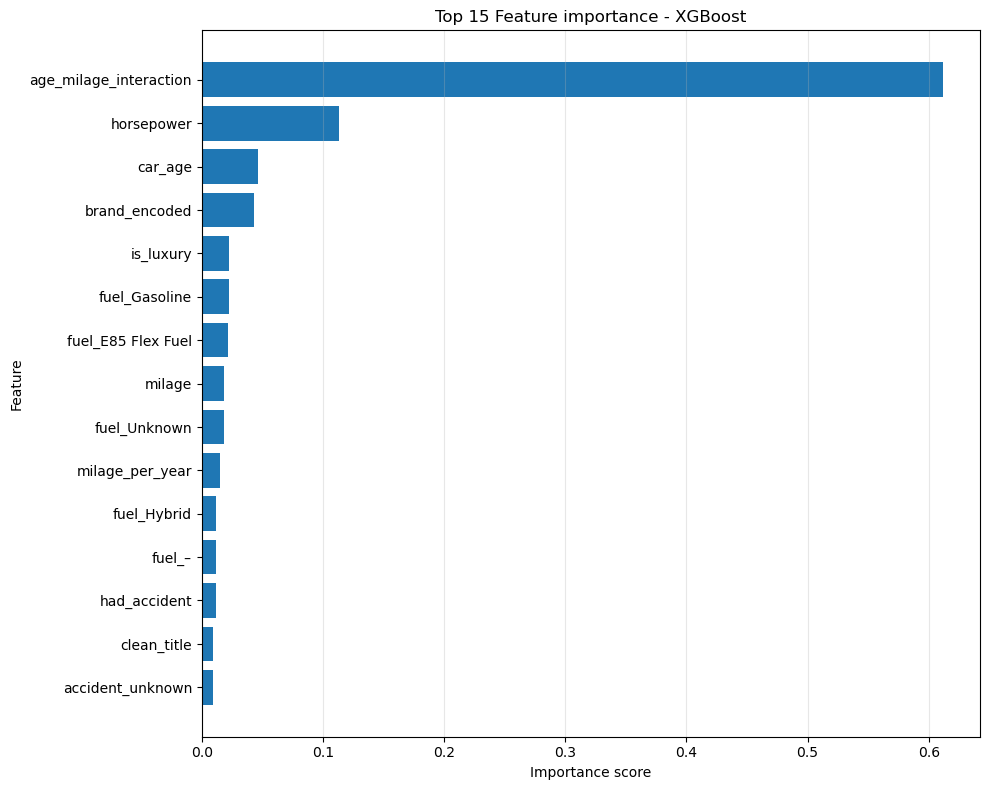

Example predictions (on filtered test set)

Car 1:
  Actual:    $15,500.00
  Predicted: $18,354.41
  Error:     $2,854.41 (+18.4%)

Car 2:
  Actual:    $48,000.00
  Predicted: $47,235.55
  Error:     $-764.45 (-1.6%)

Car 3:
  Actual:    $22,500.00
  Predicted: $22,583.38
  Error:     $83.38 (+0.4%)

Car 4:
  Actual:    $35,345.00
  Predicted: $43,951.66
  Error:     $8,606.66 (+24.4%)

Car 5:
  Actual:    $45,000.00
  Predicted: $42,995.49
  Error:     $-2,004.51 (-4.5%)
Saving model artifacts
Best model (XGBoost) saved: car_price_model.pkl
Preprocessing pipeline saved: preprocessing_pipeline.pkl
Target encoder saved: target_encoder.pkl
Metadata saved: model_metadata.pkl
Testing inference workflow

Model metadata:
  Model type: XGBoost
  Trained on: 2026-02-16 19:03:45
  Test R^2: 0.7956
  Test MAE: $6,268.63
  Price range: $-32,374 - $99,422

Sample car (raw data):
  Brand: Lexus
  Model: IS 300 Base
  Year:  2018

  Actual price:    $28,000.00
  Predicted price: $33,273.90
  Differe

In [75]:
if __name__ == "__main__":
    main()